# Defaultable Bonds and Credit Default Swaps (CDS) Pricing in Python


## What you will learn

1. How to convert risk-neutral default probability / hazard rates into survival probabilities.
2. How to price a defaultable coupon bond with recovery.
3. How to calibrate hazard rates from market bond prices.
4. How to price a CDS with:
   - fixed premium payments,
   - accrued premium on default,
   - protection payment on default.
5. How to reproduce the spreadsheet CDS pricing table in Python.
6. How to run a Monte Carlo simulation of default timing and compare it with the analytical CDS value.



In [1]:
# If you run this notebook locally and a package is missing, install:
# pip install numpy pandas scipy matplotlib

from dataclasses import dataclass
from typing import Optional, Sequence, Dict, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import minimize

pd.options.display.float_format = "{:,.8f}".format

print("Ready. This version does not read any Excel file; all spreadsheet example values are defined directly as Python inputs.")


Workbook path: /mnt/data/Bonds_and_cds_v2.xlsx


## 1. Core mathematics

### Hazard rate and survival probability

Let $h_k$ be the conditional default probability in period $k$.  
Let $q(t_k)$ be the risk-neutral survival probability up to payment date $t_k$.

$$
q(t_0)=1
$$

$$
q(t_k)=q(t_{k-1})(1-h_k)
$$

The probability of default during period $k$, meaning between $t_{k-1}$ and $t_k$, is:

$$
\Pr(t_{k-1}<\tau\leq t_k)=q(t_{k-1})-q(t_k)=q(t_{k-1})h_k
$$

### Discount factor

If the deterministic risk-free rate is $r$, compounded $m$ times per year:

$$
d(0,t)=\frac{1}{(1+r/m)^{mt}}
$$

For continuous compounding:

$$
d(0,t)=e^{-rt}
$$


In [2]:
def discount_factors(
    times: Sequence[float],
    annual_rate: float,
    compounding_frequency: Optional[int] = 1,
    continuous: bool = False,
) -> np.ndarray:
    """
    Convert payment times into risk-free discount factors.

    Parameters
    ----------
    times:
        Payment times in years. Example for quarterly payments: [0.25, 0.50, 0.75, ...].
    annual_rate:
        Annual risk-free rate as a decimal. Example: 0.05 for 5%.
    compounding_frequency:
        Number of compounding periods per year.
        Example: 2 = semiannual compounding, 4 = quarterly compounding.
        If None, simple interest is used.
    continuous:
        If True, use continuous compounding.

    Returns
    -------
    NumPy array of discount factors d(0,t).
    """
    times = np.asarray(times, dtype=float)

    if continuous:
        return np.exp(-annual_rate * times)

    if compounding_frequency is None:
        return 1.0 / (1.0 + annual_rate * times)

    return 1.0 / (1.0 + annual_rate / compounding_frequency) ** (compounding_frequency * times)


def survival_from_hazards(hazards: Sequence[float], q0: float = 1.0) -> np.ndarray:
    """
    Convert period hazard rates into survival probabilities.

    hazards[k] is the conditional default probability during period k+1.
    Output has length len(hazards)+1:
        q[0] = survival at t0
        q[1] = survival at t1
        ...
    """
    hazards = np.asarray(hazards, dtype=float)
    q = np.empty(len(hazards) + 1)
    q[0] = q0

    for i, h in enumerate(hazards, start=1):
        if h < 0 or h > 1:
            raise ValueError(f"Hazard rate must be between 0 and 1. Found {h}.")
        q[i] = q[i - 1] * (1.0 - h)

    return q


def default_probs_from_survival(q: Sequence[float]) -> np.ndarray:
    """
    Period default probability:
        default_prob[k] = q(t_k) before period - q(t_{k+1}) after period
    """
    q = np.asarray(q, dtype=float)
    return q[:-1] - q[1:]


def repeat_hazard_curve(
    bucket_hazards: Sequence[float],
    repeats_per_bucket: int,
    n_periods: Optional[int] = None,
) -> np.ndarray:
    """
    Expand a bucketed hazard curve into period-by-period hazards.

    Example:
        annual_hazards = [0.02, 0.03]
        repeats_per_bucket = 2 for semiannual periods
        result = [0.02, 0.02, 0.03, 0.03]

    If n_periods is given and the expanded curve is too short, the final hazard is repeated.
    """
    expanded = np.repeat(np.asarray(bucket_hazards, dtype=float), repeats_per_bucket)

    if n_periods is not None:
        if len(expanded) < n_periods:
            expanded = np.r_[expanded, np.repeat(expanded[-1], n_periods - len(expanded))]
        expanded = expanded[:n_periods]

    return expanded

## 2. Defaultable coupon bond with recovery

Assume a bond has:

| Symbol | Meaning |
|---|---|
| $F$ | Face value |
| $c$ | Coupon amount paid on each coupon date if no default |
| $R$ | Recovery rate as a fraction of face value |
| $q(t_k)$ | Survival probability up to coupon date $t_k$ |
| $d(0,t_k)$ | Risk-free discount factor |
| $q(t_{k-1})-q(t_k)$ | Probability of default during period $k$ |

The defaultable fixed-coupon bond price is:

$$
\bar{P}(0)
=
\sum_{k=1}^{n} c q(t_k)d(0,t_k)
+
Fq(t_n)d(0,t_n)
+
RF\sum_{k=1}^{n}\left(q(t_{k-1})-q(t_k)\right)d(0,t_k)
$$

This formula has three parts:

1. Present value of expected coupons.
2. Present value of expected face value.
3. Present value of expected recovery payments.


In [3]:
@dataclass
class BondSpec:
    name: str
    maturity_years: float
    coupon_amount: float
    recovery_rate: float
    face: float = 100.0


def price_defaultable_bond(
    face: float,
    coupon_amount: float,
    recovery_rate: float,
    maturity_years: float,
    coupon_frequency: int,
    hazards: Sequence[float],
    annual_rate: Optional[float] = None,
    discount: Optional[Sequence[float]] = None,
    compounding_frequency: Optional[int] = None,
) -> Dict[str, object]:
    """
    Price a defaultable coupon bond using risk-neutral survival probabilities.

    Parameters
    ----------
    face:
        Face value F.
    coupon_amount:
        Coupon amount c paid every coupon date if the issuer has not defaulted.
        Example: face=100, semiannual coupon amount=5 means 5 is paid every 6 months.
    recovery_rate:
        Recovery rate R as fraction of face. Example: 0.40 means 40% of face.
    maturity_years:
        Maturity in years.
    coupon_frequency:
        Number of coupon payments per year. Example: 2 = semiannual.
    hazards:
        Period-by-period hazard rates. Length must cover maturity_years * coupon_frequency periods.
    annual_rate:
        Risk-free annual rate used to generate discount factors if discount is not supplied.
    discount:
        Optional custom discount factors. If supplied, annual_rate is ignored.
    compounding_frequency:
        Risk-free compounding frequency. Defaults to coupon_frequency.

    Returns
    -------
    Dictionary with:
        price: bond price
        table: calculation table by period
    """
    n_periods = int(round(maturity_years * coupon_frequency))
    h = np.asarray(hazards, dtype=float)[:n_periods]

    if len(h) < n_periods:
        raise ValueError(f"Need at least {n_periods} hazard rates, got {len(h)}.")

    times = np.arange(1, n_periods + 1) / coupon_frequency

    if discount is None:
        if annual_rate is None:
            raise ValueError("Provide either annual_rate or discount.")
        if compounding_frequency is None:
            compounding_frequency = coupon_frequency
        discount = discount_factors(times, annual_rate, compounding_frequency)
    else:
        discount = np.asarray(discount, dtype=float)[:n_periods]

    q = survival_from_hazards(h)
    default_prob = default_probs_from_survival(q)

    coupon_cf = np.full(n_periods, coupon_amount, dtype=float)
    face_cf = np.zeros(n_periods)
    face_cf[-1] = face

    expected_coupon_and_face = q[1:] * (coupon_cf + face_cf)
    expected_recovery = recovery_rate * face * default_prob
    expected_cf = expected_coupon_and_face + expected_recovery
    pv = discount * expected_cf

    table = pd.DataFrame({
        "period": np.arange(1, n_periods + 1),
        "time_years": times,
        "hazard": h,
        "survival_q": q[1:],
        "default_prob": default_prob,
        "discount": discount,
        "coupon_plus_face_if_survive": coupon_cf + face_cf,
        "expected_coupon_face": expected_coupon_and_face,
        "expected_recovery": expected_recovery,
        "expected_cf": expected_cf,
        "pv": pv,
    })

    return {
        "price": float(pv.sum()),
        "table": table,
    }

### 2.1 Spreadsheet-style bond-pricing example 


The spreadsheet-style assumptions are:

- risk-free rate $r=5\%$,
- semiannual coupon periods, so coupon frequency $=2$,
- face value $F=100$,
- constant semiannual hazard rate $h=2\%$,
- five example bonds with different maturities, coupons, and recovery rates.

For validation, the expected spreadsheet prices are typed directly as constants in `expected_spreadsheet_prices`.


In [4]:
# ===== Spreadsheet-style bond inputs, typed directly in Python =====

risk_free_rate_bond = 0.05
coupon_frequency = 2
face_value = 100.0

# Ten semiannual periods = 5 years. Each period has 2% conditional default probability.
hazards_6m = np.full(10, 0.02)

bond_specs = [
    BondSpec(name="1Y bond: c=5, R=10%", maturity_years=1, coupon_amount=5, recovery_rate=0.10),
    BondSpec(name="2Y bond: c=2, R=25%", maturity_years=2, coupon_amount=2, recovery_rate=0.25),
    BondSpec(name="3Y bond: c=5, R=50%", maturity_years=3, coupon_amount=5, recovery_rate=0.50),
    BondSpec(name="4Y bond: c=5, R=10%", maturity_years=4, coupon_amount=5, recovery_rate=0.10),
    BondSpec(name="5Y bond: c=10, R=20%", maturity_years=5, coupon_amount=10, recovery_rate=0.20),
]

# These are the spreadsheet prices from the original Pricing sheet, entered manually.
# They are only used for checking that the Python function reproduces the spreadsheet result.
expected_spreadsheet_prices = np.array([
    101.14503271861986,
    92.54810799469595,
    107.34660550543053,
    104.02318888855226,
    145.81584369434674,
])

pricing_rows = []
for spec, expected_price in zip(bond_specs, expected_spreadsheet_prices):
    result = price_defaultable_bond(
        face=spec.face,
        coupon_amount=spec.coupon_amount,
        recovery_rate=spec.recovery_rate,
        maturity_years=spec.maturity_years,
        coupon_frequency=coupon_frequency,
        hazards=hazards_6m,
        annual_rate=risk_free_rate_bond,
        compounding_frequency=coupon_frequency,
    )
    pricing_rows.append({
        "bond": spec.name,
        "python_price": result["price"],
        "expected_spreadsheet_price": expected_price,
        "difference": result["price"] - expected_price,
    })

bond_pricing_result = pd.DataFrame(pricing_rows)
display(bond_pricing_result)


,bond,python_price,spreadsheet_price,difference
0,"1Y bond: c=5, R=10%",101.14503272,101.14503272,0.00000000
1,"2Y bond: c=2, R=25%",92.54810799,92.54810799,0.00000000
2,"3Y bond: c=5, R=50%",107.34660551,107.34660551,0.00000000
3,"4Y bond: c=5, R=10%",104.02318889,104.02318889,0.00000000
4,"5Y bond: c=10, R=20%",145.81584369,145.81584369,0.00000000


## 3. Hazard-rate calibration from bond prices

The PDF describes calibration as choosing hazard rates $h$ to minimize pricing error:

$$
\min_{h\geq 0}
\sum_{i=1}^{m}
\left(P_i^{mkt}-P_i(h)\right)^2
$$

where:

- $P_i^{mkt}$ is the observed market price of bond $i$,
- $P_i(h)$ is the model price generated by the hazard curve,
- $h\geq 0$ keeps default probabilities non-negative.

In practice, we often use a piecewise hazard curve.  
For example, a 5-year semiannual model can use five annual hazard buckets:

$$
$$
h_1,h_2,h_3,h_4,h_5
$$
$$

and expand it into 10 semiannual periods:

$$
$$
h_1,h_1,h_2,h_2,h_3,h_3,h_4,h_4,h_5,h_5
$$
$$


In [5]:
def calibrate_bucket_hazards(
    bond_specs: Sequence[BondSpec],
    market_prices: Sequence[float],
    annual_rate: float,
    coupon_frequency: int = 2,
    periods_per_bucket: int = 2,
    initial_guess: float = 0.02,
    bounds: Tuple[float, float] = (0.0, 1.0),
) -> Dict[str, object]:
    """
    Calibrate a piecewise hazard curve from market bond prices.

    This function uses one hazard bucket per bond by default.
    Example: 5 bonds -> 5 hazard buckets.

    Returns optimizer result, fitted bucket hazards, expanded hazards,
    model prices, and an error table.
    """
    market_prices = np.asarray(market_prices, dtype=float)
    n_buckets = len(bond_specs)
    x0 = np.full(n_buckets, initial_guess, dtype=float)

    max_periods = int(round(max(b.maturity_years for b in bond_specs) * coupon_frequency))

    def curve_from_x(x: Sequence[float]) -> np.ndarray:
        return repeat_hazard_curve(x, periods_per_bucket, n_periods=max_periods)

    def model_prices(x: Sequence[float]) -> np.ndarray:
        h_curve = curve_from_x(x)
        prices = []
        for b in bond_specs:
            price = price_defaultable_bond(
                face=b.face,
                coupon_amount=b.coupon_amount,
                recovery_rate=b.recovery_rate,
                maturity_years=b.maturity_years,
                coupon_frequency=coupon_frequency,
                hazards=h_curve,
                annual_rate=annual_rate,
                compounding_frequency=coupon_frequency,
            )["price"]
            prices.append(price)
        return np.asarray(prices)

    def objective(x: Sequence[float]) -> float:
        err = market_prices - model_prices(x)
        return float(np.sum(err ** 2))

    opt_result = minimize(
        objective,
        x0,
        method="L-BFGS-B",
        bounds=[bounds] * n_buckets,
    )

    fitted_bucket_hazards = opt_result.x
    fitted_hazard_curve = curve_from_x(fitted_bucket_hazards)
    fitted_prices = model_prices(fitted_bucket_hazards)

    error_table = pd.DataFrame({
        "bond": [b.name for b in bond_specs],
        "market_price": market_prices,
        "model_price": fitted_prices,
        "pricing_error": fitted_prices - market_prices,
    })

    return {
        "optimizer_result": opt_result,
        "bucket_hazards": fitted_bucket_hazards,
        "hazard_curve": fitted_hazard_curve,
        "model_prices": fitted_prices,
        "error_table": error_table,
        "sse": float(opt_result.fun),
    }


# Market prices are direct manual inputs.
# Here we use the spreadsheet-style prices from the previous section.
market_prices = expected_spreadsheet_prices.copy()

calibration = calibrate_bucket_hazards(
    bond_specs=bond_specs,
    market_prices=market_prices,
    annual_rate=risk_free_rate_bond,
    coupon_frequency=2,
    periods_per_bucket=2,
    initial_guess=0.015,
)

print("Calibrated annual hazard buckets:")
display(pd.DataFrame({
    "bucket_year": np.arange(1, len(calibration["bucket_hazards"]) + 1),
    "hazard": calibration["bucket_hazards"],
}))

print("Expanded semiannual hazard curve:")
display(pd.DataFrame({
    "semiannual_period": np.arange(1, len(calibration["hazard_curve"]) + 1),
    "hazard": calibration["hazard_curve"],
}))

print("Calibration error table:")
display(calibration["error_table"])
print("SSE:", calibration["sse"])


Calibrated annual hazard buckets:


,bucket_year,hazard
0,1,0.02000007
1,2,0.01999987
2,3,0.01999988
3,4,0.02000008
4,5,0.02000027


Expanded semiannual hazard curve:


,semiannual_period,hazard
0,1,0.02000007
1,2,0.02000007
2,3,0.01999987
3,4,0.01999987
4,5,0.01999988
5,6,0.01999988
6,7,0.02000008
7,8,0.02000008
8,9,0.02000027
9,10,0.02000027


Calibration error table:


,bond,market_price,model_price,pricing_error
0,"1Y bond: c=5, R=10%",101.14503272,101.14502002,-0.00001270
1,"2Y bond: c=2, R=25%",92.54810799,92.54811606,0.00000807
2,"3Y bond: c=5, R=50%",107.34660551,107.34662132,0.00001581
3,"4Y bond: c=5, R=10%",104.02318889,104.02320544,0.00001655
4,"5Y bond: c=10, R=20%",145.81584369,145.81583063,-0.00001306


SSE: 9.21018146168953e-10


## 4. Credit Default Swap (CDS) pricing

A CDS value to the protection buyer is:

$$
\text{CDS value}
=
\text{Protection Leg}
-
\text{Premium Leg}
$$

### Premium leg

If payment interval is $\delta$, notional is $N$, and spread is $S$ as a decimal, then fixed premium payments are:

$$
\delta S N
$$

Expected present value of fixed premium payments:

$$
\text{Fixed Premium PV}
=
\delta S N
\sum_{k=1}^{n}q(t_k)d(0,t_k)
$$

### Accrued premium on default

Assuming default is uniformly distributed inside each payment interval, the expected accrued premium is about half a period:

$$
\text{Accrued Premium PV}
=
\frac{\delta}{2}SN
\sum_{k=1}^{n}\left(q(t_{k-1})-q(t_k)\right)d(0,t_k)
$$

### Protection leg

If the reference entity defaults, the protection seller pays:

$$
(1-R)N
$$

Expected present value of protection:

$$
\text{Protection PV}
=
(1-R)N
\sum_{k=1}^{n}\left(q(t_{k-1})-q(t_k)\right)d(0,t_k)
$$

### Par spread

The par spread is the spread that makes CDS value equal to zero:

$$
S_{par}
=
\frac{
(1-R)\sum_{k=1}^{n}\left(q(t_{k-1})-q(t_k)\right)d(0,t_k)
}{
\delta\sum_{k=1}^{n}q(t_k)d(0,t_k)
+
\frac{\delta}{2}\sum_{k=1}^{n}\left(q(t_{k-1})-q(t_k)\right)d(0,t_k)
}
$$

Equivalent denominator form:

$$
S_{par}
=
\frac{
(1-R)\sum_{k=1}^{n}\left(q(t_{k-1})-q(t_k)\right)d(0,t_k)
}{
\frac{\delta}{2}\sum_{k=1}^{n}\left(q(t_{k-1})+q(t_k)\right)d(0,t_k)
}
$$

For small constant hazard $h$:

$$
S_{par}\approx \frac{(1-R)h}{1-h/2}
\approx (1-R)h
$$


In [6]:
def cds_valuation(
    spread_bps: float,
    notional: float,
    recovery_rate: float,
    hazards: Sequence[float],
    annual_rate: Optional[float] = None,
    discount: Optional[Sequence[float]] = None,
    payment_frequency: int = 4,
    compounding_frequency: Optional[int] = None,
    continuous: bool = False,
) -> Dict[str, object]:
    """
    Price a CDS analytically from a period-by-period hazard curve.

    Parameters
    ----------
    spread_bps:
        CDS spread in basis points per year. Example: 160 means 160 bps = 1.60%.
    notional:
        Notional N.
    recovery_rate:
        Recovery rate R as decimal. Example: 0.45.
    hazards:
        Period-by-period hazard rates matching the premium payment frequency.
        Example: for quarterly payments over 2 years, provide 8 hazard rates.
    annual_rate:
        Risk-free annual rate used to generate discount factors.
    discount:
        Optional custom discount factors.
    payment_frequency:
        Number of premium payments per year. Example: 4 = quarterly.
    compounding_frequency:
        Risk-free compounding frequency. Defaults to payment_frequency.

    Returns
    -------
    Dictionary with summary and calculation table.
    """
    h = np.asarray(hazards, dtype=float)
    n_periods = len(h)
    delta = 1.0 / payment_frequency
    times = np.arange(1, n_periods + 1) * delta

    if discount is None:
        if annual_rate is None:
            raise ValueError("Provide either annual_rate or discount.")
        if compounding_frequency is None:
            compounding_frequency = payment_frequency
        discount = discount_factors(
            times,
            annual_rate=annual_rate,
            compounding_frequency=compounding_frequency,
            continuous=continuous,
        )
    else:
        discount = np.asarray(discount, dtype=float)[:n_periods]

    q = survival_from_hazards(h)
    default_prob = default_probs_from_survival(q)

    spread_decimal = spread_bps / 10_000.0

    fixed_premium_pv_each = notional * spread_decimal * delta * q[1:] * discount
    accrued_premium_pv_each = notional * spread_decimal * (delta / 2.0) * default_prob * discount
    protection_pv_each = notional * (1.0 - recovery_rate) * default_prob * discount

    fixed_premium_leg = fixed_premium_pv_each.sum()
    accrued_premium_leg = accrued_premium_pv_each.sum()
    premium_leg = fixed_premium_leg + accrued_premium_leg
    protection_leg = protection_pv_each.sum()
    value_to_buyer = protection_leg - premium_leg

    denominator = (
        delta * np.sum(q[1:] * discount)
        + (delta / 2.0) * np.sum(default_prob * discount)
    )
    par_spread_decimal = (1.0 - recovery_rate) * np.sum(default_prob * discount) / denominator
    par_spread_bps = par_spread_decimal * 10_000.0

    table = pd.DataFrame({
        "period": np.arange(1, n_periods + 1),
        "time_years": times,
        "hazard": h,
        "survival_q": q[1:],
        "default_prob": default_prob,
        "discount": discount,
        "fixed_premium_pv": fixed_premium_pv_each,
        "accrued_premium_pv": accrued_premium_pv_each,
        "protection_pv": protection_pv_each,
    })

    summary = {
        "spread_bps": float(spread_bps),
        "notional": float(notional),
        "recovery_rate": float(recovery_rate),
        "fixed_premium_leg": float(fixed_premium_leg),
        "accrued_premium_leg": float(accrued_premium_leg),
        "premium_leg": float(premium_leg),
        "protection_leg": float(protection_leg),
        "value_to_buyer": float(value_to_buyer),
        "par_spread_bps": float(par_spread_bps),
    }

    return {
        "summary": summary,
        "table": table,
    }


def cds_par_spread_bps(
    notional: float,
    recovery_rate: float,
    hazards: Sequence[float],
    annual_rate: float,
    payment_frequency: int = 4,
    compounding_frequency: Optional[int] = None,
) -> float:
    """
    Convenience wrapper.
    Because notional cancels out in the par spread formula, notional can be any positive number.
    """
    result = cds_valuation(
        spread_bps=1.0,
        notional=notional,
        recovery_rate=recovery_rate,
        hazards=hazards,
        annual_rate=annual_rate,
        payment_frequency=payment_frequency,
        compounding_frequency=compounding_frequency,
    )
    return result["summary"]["par_spread_bps"]

### 4.1 Spreadsheet-style CDS pricing table 

The original spreadsheet-style setup is:

- spread $S=218.88953946553033$ bps,
- notional $N=1{,}000{,}000$,
- recovery rate $R=45\%$,
- risk-free interest rate $r=1\%$,
- quarterly payment months $3,6,9,12,15,18,21,24$,
- period hazard rates defined directly in the input dictionary.

The expected premium leg, protection leg, and value are also typed directly for validation.


In [7]:
# ===== Spreadsheet-style CDS inputs, typed directly in Python =====

cds_inputs = {
    "spread_bps": 218.88953946553033,
    "notional": 1_000_000.0,
    "recovery_rate": 0.45,
    "annual_rate": 0.01,
    "payment_frequency": 4,
    "months": np.array([3, 6, 9, 12, 15, 18, 21, 24], dtype=float),

    # These are the period hazard rates used by the spreadsheet logic.
    # They are conditional default probabilities for each quarterly premium period.
    "period_hazards": np.array([
        0.01007028652009901,
        0.01007028652009901,
        0.01007028652009901,
        0.01007028652009901,
        0.00972155166933149,
        0.00972155166933149,
        0.00972155166933149,
        0.00972155166933149,
    ]),

    # Expected spreadsheet outputs, typed directly for validation.
    "expected_summary": {
        "premium_leg": 41603.28046534117,
        "protection_leg": 41603.280465341166,
        "value": 0.0,
        "par_spread_bps": 218.88953946553033,
    },
}

cds_result = cds_valuation(
    spread_bps=cds_inputs["spread_bps"],
    notional=cds_inputs["notional"],
    recovery_rate=cds_inputs["recovery_rate"],
    hazards=cds_inputs["period_hazards"],
    annual_rate=cds_inputs["annual_rate"],
    payment_frequency=cds_inputs["payment_frequency"],
    compounding_frequency=cds_inputs["payment_frequency"],
)

summary_df = pd.DataFrame({
    "metric": ["premium_leg", "protection_leg", "value_to_buyer", "par_spread_bps"],
    "python": [
        cds_result["summary"]["premium_leg"],
        cds_result["summary"]["protection_leg"],
        cds_result["summary"]["value_to_buyer"],
        cds_result["summary"]["par_spread_bps"],
    ],
    "expected_spreadsheet_value": [
        cds_inputs["expected_summary"]["premium_leg"],
        cds_inputs["expected_summary"]["protection_leg"],
        cds_inputs["expected_summary"]["value"],
        cds_inputs["expected_summary"]["par_spread_bps"],
    ],
})
summary_df["difference"] = summary_df["python"] - summary_df["expected_spreadsheet_value"]

display(summary_df)
display(cds_result["table"])


,metric,python,spreadsheet,difference
0,premium_leg,"41,603.28046534","41,603.28046534",0.00000000
1,protection_leg,"41,603.28046534","41,603.28046534",0.00000000
2,value_to_buyer,0.00000000,0.00000000,0.00000000
3,par_spread_bps,218.88953947,218.88953947,0.00000000


,period,time_years,hazard,survival_q,default_prob,discount,fixed_premium_pv,accrued_premium_pv,protection_pv
0,1,0.25000000,0.01007029,0.98992971,0.01007029,0.99750623,"5,403.62242112",27.48479275,"5,524.84547237"
1,2,0.50000000,0.01007029,0.97996084,0.00996888,0.99501869,"5,335.86672827",27.14016261,"5,455.56977106"
2,3,0.75000000,0.01007029,0.97009235,0.00986849,0.99253734,"5,268.96061993",26.79985376,"5,387.16271355"
3,4,1.00000000,0.01007029,0.96032324,0.00976911,0.99006219,"5,202.89344322",26.46381202,"5,319.61340798"
4,5,1.25000000,0.00972155,0.95098741,0.00933583,0.98759321,"5,139.46458432",25.22703114,"5,071.00235547"
5,6,1.50000000,0.00972155,0.94174234,0.00924507,0.98513038,"5,076.80899133",24.91948654,"5,009.18139058"
6,7,1.75000000,0.00972155,0.93258714,0.00915520,0.98267370,"5,014.91723732",24.61569123,"4,948.11408964"
7,8,2.00000000,0.00972155,0.92352095,0.00906619,0.98022314,"4,953.78001025",24.31559952,"4,887.79126469"


## 5. Manual scenario input

Use this cell to price a CDS from your own known parameters.

Example inputs:

- $N=1{,}000{,}000$
- $R=45\%$
- $S=160$ bps
- risk-free rate $r=1\%$
- quarterly payments for 2 years
- constant quarterly hazard $h=1\%$


In [8]:
# ===== Manual scenario input =====
# Change only this block when you want to price a new CDS.

manual_notional = 1_000_000
manual_recovery_rate = 0.45
manual_spread_bps = 160.0
manual_annual_rate = 0.01
manual_payment_frequency = 4
manual_maturity_years = 2

manual_n_periods = int(manual_payment_frequency * manual_maturity_years)
manual_hazards = np.full(manual_n_periods, 0.01)  # 1% conditional default probability each quarter

manual_cds = cds_valuation(
    spread_bps=manual_spread_bps,
    notional=manual_notional,
    recovery_rate=manual_recovery_rate,
    hazards=manual_hazards,
    annual_rate=manual_annual_rate,
    payment_frequency=manual_payment_frequency,
    compounding_frequency=manual_payment_frequency,
)

print("Manual CDS summary")
display(pd.DataFrame([manual_cds["summary"]]).T.rename(columns={0: "value"}))

print("Manual CDS period table")
display(manual_cds["table"])


Manual CDS summary


,value
spread_bps,160.00000000
notional,"1,000,000.00000000"
recovery_rate,0.45000000
fixed_premium_leg,"30,255.76231189"
accrued_premium_leg,152.80688036
premium_leg,"30,408.56919225"
protection_leg,"42,021.89209985"
value_to_buyer,"11,613.32290759"
par_spread_bps,221.10552764


Manual CDS period table


,period,time_years,hazard,survival_q,default_prob,discount,fixed_premium_pv,accrued_premium_pv,protection_pv
0,1,0.25000000,0.01000000,0.99000000,0.01000000,0.99750623,"3,950.12468828",19.95012469,"5,486.28428928"
1,2,0.50000000,0.01000000,0.98010000,0.00990000,0.99501869,"3,900.87126324",19.70137002,"5,417.87675450"
2,3,0.75000000,0.01000000,0.97029900,0.00980100,0.99253734,"3,852.23197068",19.45571702,"5,350.32218150"
3,4,1.00000000,0.01000000,0.96059601,0.00970299,0.99006219,"3,804.19915309",19.21312704,"5,283.60993485"
4,5,1.25000000,0.01000000,0.95099005,0.00960596,0.98759321,"3,756.76524844",18.97356186,"5,217.72951172"
5,6,1.50000000,0.01000000,0.94148015,0.00950990,0.98513038,"3,709.92278898",18.73698378,"5,152.67054025"
6,7,1.75000000,0.01000000,0.93206535,0.00941480,0.98267370,"3,663.66440009",18.50335556,"5,088.42277790"
7,8,2.00000000,0.01000000,0.92274469,0.00932065,0.98022314,"3,617.98279909",18.27264040,"5,024.97610985"


## 6. Monte Carlo simulation of CDS cash flows

The analytical CDS formula uses expected values under the risk-neutral probability measure.  
A simulation should converge to the analytical value when the number of paths is large.

Simulation logic per path:

1. Start alive at $t_0$.
2. In each period $k$, default occurs with probability $h_k$ conditional on survival up to the start of the period.
3. If no default occurs in period $k$, the buyer pays the fixed premium at $t_k$.
4. If default occurs in period $k$:
   - the buyer pays accrued premium,
   - the buyer receives protection $(1-R)N$,
   - the contract terminates.

For accrued premium, this simulation draws a uniform default time inside the period.  
That gives the same expected half-period accrued premium used in the analytical formula.


In [9]:
def simulate_cds_cashflows(
    spread_bps: float,
    notional: float,
    recovery_rate: float,
    hazards: Sequence[float],
    annual_rate: float,
    payment_frequency: int = 4,
    compounding_frequency: Optional[int] = None,
    n_paths: int = 200_000,
    seed: int = 42,
) -> Dict[str, object]:
    """
    Monte Carlo simulation for CDS cash flows.

    Returns average PV of:
        fixed premiums,
        accrued premiums,
        total premium leg,
        protection leg,
        value to buyer.
    """
    rng = np.random.default_rng(seed)

    h = np.asarray(hazards, dtype=float)
    n_periods = len(h)
    delta = 1.0 / payment_frequency
    times = np.arange(1, n_periods + 1) * delta

    if compounding_frequency is None:
        compounding_frequency = payment_frequency

    dfs = discount_factors(times, annual_rate, compounding_frequency)
    spread_decimal = spread_bps / 10_000.0

    fixed_premium_amount = notional * spread_decimal * delta
    protection_amount = notional * (1.0 - recovery_rate)

    fixed_pv = np.zeros(n_paths)
    accrued_pv = np.zeros(n_paths)
    protection_pv = np.zeros(n_paths)

    alive = np.ones(n_paths, dtype=bool)

    for k in range(n_periods):
        alive_idx = np.where(alive)[0]
        if len(alive_idx) == 0:
            break

        # Conditional default during this period.
        u = rng.random(len(alive_idx))
        default_now_idx = alive_idx[u < h[k]]
        survive_now_idx = alive_idx[u >= h[k]]

        # Survivors pay the full fixed premium at t_k.
        fixed_pv[survive_now_idx] += fixed_premium_amount * dfs[k]

        # Defaulters pay accrued premium and receive protection.
        # Draw default time uniformly within the period.
        if len(default_now_idx) > 0:
            time_from_period_start = rng.random(len(default_now_idx)) * delta
            accrued_fraction = time_from_period_start
            accrued_pv[default_now_idx] += notional * spread_decimal * accrued_fraction * dfs[k]
            protection_pv[default_now_idx] += protection_amount * dfs[k]
            alive[default_now_idx] = False

    premium_pv = fixed_pv + accrued_pv
    value_to_buyer = protection_pv - premium_pv

    summary = {
        "fixed_premium_leg_mc": float(fixed_pv.mean()),
        "accrued_premium_leg_mc": float(accrued_pv.mean()),
        "premium_leg_mc": float(premium_pv.mean()),
        "protection_leg_mc": float(protection_pv.mean()),
        "value_to_buyer_mc": float(value_to_buyer.mean()),
        "default_frequency_mc": float((protection_pv > 0).mean()),
        "n_paths": int(n_paths),
    }

    return {
        "summary": summary,
        "path_values": pd.DataFrame({
            "premium_pv": premium_pv,
            "protection_pv": protection_pv,
            "value_to_buyer": value_to_buyer,
        })
    }


simulation = simulate_cds_cashflows(
    spread_bps=cds_inputs["spread_bps"],
    notional=cds_inputs["notional"],
    recovery_rate=cds_inputs["recovery_rate"],
    hazards=cds_inputs["period_hazards"],
    annual_rate=cds_inputs["annual_rate"],
    payment_frequency=cds_inputs["payment_frequency"],
    compounding_frequency=cds_inputs["payment_frequency"],
    n_paths=200_000,
    seed=7,
)

comparison = pd.DataFrame({
    "metric": ["premium_leg", "protection_leg", "value_to_buyer"],
    "analytical": [
        cds_result["summary"]["premium_leg"],
        cds_result["summary"]["protection_leg"],
        cds_result["summary"]["value_to_buyer"],
    ],
    "monte_carlo": [
        simulation["summary"]["premium_leg_mc"],
        simulation["summary"]["protection_leg_mc"],
        simulation["summary"]["value_to_buyer_mc"],
    ],
})
comparison["mc_minus_analytical"] = comparison["monte_carlo"] - comparison["analytical"]

display(pd.DataFrame([simulation["summary"]]).T.rename(columns={0: "value"}))
display(comparison)

,value
fixed_premium_leg_mc,"41,404.16454271"
accrued_premium_leg_mc,206.28345207
premium_leg_mc,"41,610.44799478"
protection_leg_mc,"41,650.22219082"
value_to_buyer_mc,39.77419604
default_frequency_mc,0.07657000
n_paths,"200,000.00000000"


,metric,analytical,monte_carlo,mc_minus_analytical
0,premium_leg,"41,603.28046534","41,610.44799478",7.16752944
1,protection_leg,"41,603.28046534","41,650.22219082",46.94172548
2,value_to_buyer,0.00000000,39.77419604,39.77419604


## 7. Sensitivity: par spread versus hazard and recovery

The approximation $S \approx (1-R)h$ tells us:

- higher hazard rate $h$ should increase CDS spread,
- higher recovery $R$ should decrease CDS spread.

The code below stresses the hazard curve and recovery rate to visualize this relationship.


,hazard_multiplier,recovery_rate,par_spread_bps
0,0.25000000,0.25000000,74.32438573
1,0.34210526,0.25000000,101.75678956
2,0.43421053,0.25000000,129.21603922
3,0.52631579,0.25000000,156.70217636
4,0.61842105,0.25000000,184.21524265
5,0.71052632,0.25000000,211.75527984
6,0.80263158,0.25000000,239.32232975
7,0.89473684,0.25000000,266.91643427
8,0.98684211,0.25000000,294.53763535
9,1.07894737,0.25000000,322.18597501


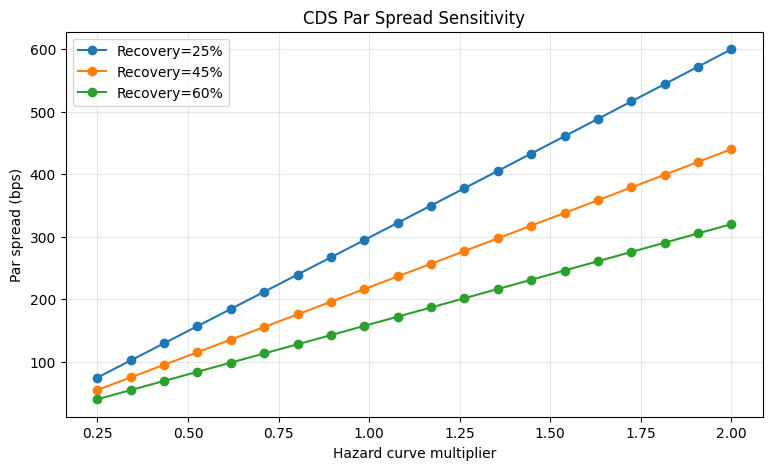

In [10]:
base_hazards = cds_inputs["period_hazards"]
hazard_multipliers = np.linspace(0.25, 2.0, 20)
recovery_scenarios = [0.25, 0.45, 0.60]

sensitivity_rows = []
for rec in recovery_scenarios:
    for m in hazard_multipliers:
        stressed_hazards = np.clip(base_hazards * m, 0, 0.999)
        par_bps = cds_par_spread_bps(
            notional=cds_inputs["notional"],
            recovery_rate=rec,
            hazards=stressed_hazards,
            annual_rate=cds_inputs["annual_rate"],
            payment_frequency=cds_inputs["payment_frequency"],
            compounding_frequency=cds_inputs["payment_frequency"],
        )
        sensitivity_rows.append({
            "hazard_multiplier": m,
            "recovery_rate": rec,
            "par_spread_bps": par_bps,
        })

sensitivity_df = pd.DataFrame(sensitivity_rows)
display(sensitivity_df.head(10))

plt.figure(figsize=(9, 5))
for rec in recovery_scenarios:
    tmp = sensitivity_df[sensitivity_df["recovery_rate"] == rec]
    plt.plot(tmp["hazard_multiplier"], tmp["par_spread_bps"], marker="o", label=f"Recovery={rec:.0%}")

plt.xlabel("Hazard curve multiplier")
plt.ylabel("Par spread (bps)")
plt.title("CDS Par Spread Sensitivity")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 8. How to adapt this notebook

### For a new defaultable bond

Use:

```python
price_defaultable_bond(
    face=100,
    coupon_amount=5,
    recovery_rate=0.40,
    maturity_years=3,
    coupon_frequency=2,
    hazards=[0.01, 0.01, 0.012, 0.012, 0.015, 0.015],
    annual_rate=0.05,
)
```

### For a new CDS

Use:

```python
cds_valuation(
    spread_bps=160,
    notional=1_000_000,
    recovery_rate=0.45,
    hazards=[0.01] * 8,
    annual_rate=0.01,
    payment_frequency=4,
)
```

### For par spread

Use:

```python
cds_par_spread_bps(
    notional=1_000_000,
    recovery_rate=0.45,
    hazards=[0.01] * 8,
    annual_rate=0.01,
    payment_frequency=4,
)
```

### For calibration

Use:

```python
calibrate_bucket_hazards(
    bond_specs=bond_specs,
    market_prices=[101, 98, 95, 90, 85],
    annual_rate=0.05,
)
```

The key idea is to always convert the formula into these arrays:

1. `times`
2. `discount`
3. `hazards`
4. `survival_q`
5. `default_prob`
6. expected cash flows
7. present values
